# Notebook 02 — Embeddings + Visualisation t-SNE
---

## 1. Installation des dépendances

In [1]:
%pip install sentence-transformers faiss-cpu scikit-learn matplotlib seaborn numpy pandas

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import pickle

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import os

sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 3. Chargement du dataset

In [3]:
df = pd.read_csv('../Datasets/snort_dataset_clean.csv')
print(f'Dataset chargé : {len(df)} entrées')

# On encode les descriptions + le contexte enrichi
df['text_to_encode'] = df['description'] + ' [' + df['attack_type'] + '] [' + df['protocol'] + ']'
print('Exemple de texte encodé :')
print(df['text_to_encode'].iloc[0])

Dataset chargé : 50 entrées
Exemple de texte encodé :
Détection d'un scan de ports SYN sur un serveur web [Port Scan] [TCP]


## 4. Chargement du modèle d'embedding

In [ ]:
MODEL_NAME = 'all-mpnet-base-v2'
print(f'Chargement du modèle : {MODEL_NAME} ...')
model = SentenceTransformer(MODEL_NAME)
print('Modèle chargé')
print(f'   Dimension des embeddings : {model.get_sentence_embedding_dimension()}')

Chargement du modèle : all-mpnet-base-v2 ...


c:\Users\takie\Desktop\Master\S2\NLP\Devoir\Devoir 3\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\takie\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9975.70it/s]


Modèle chargé
   Dimension des embeddings : 768


C:\Users\takie\AppData\Local\Temp\ipykernel_11268\3507032944.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'   Dimension des embeddings : {model.get_sentence_embedding_dimension()}')


## 5. Génération des embeddings

In [ ]:
texts = df['text_to_encode'].tolist()

print('Encodage en cours...')
embeddings = model.encode(texts, show_progress_bar=True, normalize_embeddings=True)

print(f'Embeddings générés')
print(f'   Shape : {embeddings.shape}')   
print(f'   Type  : {embeddings.dtype}')

Encodage en cours...


Batches: 100%|██████████| 2/2 [00:00<00:00,  2.23it/s]

Embeddings générés
   Shape : (50, 768)
   Type  : float32


## 6. Création et sauvegarde de l'index FAISS

In [9]:
dimension = embeddings.shape[1]

# Index cosine similarity (Inner Product sur vecteurs normalisés)
index = faiss.IndexFlatIP(dimension)
index.add(embeddings.astype('float32'))

print(f'Index FAISS créé')
print(f'   Nombre de vecteurs indexés : {index.ntotal}')

# Sauvegarde dans le dossier Embeddings/
os.makedirs('../Embeddings', exist_ok=True)
faiss.write_index(index, '../Embeddings/snort_faiss.index')
np.save('../Embeddings/snort_embeddings.npy', embeddings)

with open('../Embeddings/snort_metadata.pkl', 'wb') as f:
    pickle.dump(df.to_dict(orient='records'), f)

print('Fichiers sauvegardés :')
print('   → Embeddings/snort_faiss.index')
print('   → Embeddings/snort_embeddings.npy')
print('   → Embeddings/snort_metadata.pkl')

Index FAISS créé
   Nombre de vecteurs indexés : 50
Fichiers sauvegardés :
   → Embeddings/snort_faiss.index
   → Embeddings/snort_embeddings.npy
   → Embeddings/snort_metadata.pkl


## 7. Test de recherche avec FAISS

In [11]:
def search(query, k=3):
    """Recherche les k documents les plus similaires à la requête."""
    query_vec = model.encode([query], normalize_embeddings=True).astype('float32')
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        row = df.iloc[idx]
        results.append({
            'score'      : round(float(score), 4),
            'description': row['description'],
            'attack_type': row['attack_type'],
            'severity'   : row['severity'],
            'snort_rule' : row['snort_rule']
        })
    return results

# --- Test ---
query_test = "Détecter un scan de ports sur un serveur"
print(f'Requête : "{query_test}"\n')

for i, res in enumerate(search(query_test, k=3), 1):
    print(f'[{i}] Score={res["score"]} | {res["attack_type"]} | {res["severity"]}')
    print(f'     Description : {res["description"]}')
    print(f'     Règle Snort : {res["snort_rule"][:80]}...')
    print()

Requête : "Détecter un scan de ports sur un serveur"

[1] Score=0.8638 | Port Scan | medium
     Description : Détection d'un scan de ports SYN sur un serveur web
     Règle Snort : alert tcp any any -> $HOME_NET 80 (msg:"SYN Scan détecté"; flags:S; threshold:ty...

[2] Score=0.7362 | Port Scan | low
     Description : Scan UDP sur plage de ports pour services exposés
     Règle Snort : alert udp any any -> $HOME_NET any (msg:"UDP Port Scan"; threshold:type both, tr...

[3] Score=0.7159 | Port Scan | medium
     Description : Détection d'un scan XMAS (flags FIN+PSH+URG)
     Règle Snort : alert tcp any any -> $HOME_NET any (msg:"XMAS Scan"; flags:FPU; sid:1000046; rev...



## 8. Visualisation t-SNE des embeddings

In [13]:
print('Calcul t-SNE (peut prendre quelques secondes)...')
tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)
print('t-SNE terminé')

Calcul t-SNE (peut prendre quelques secondes)...
t-SNE terminé


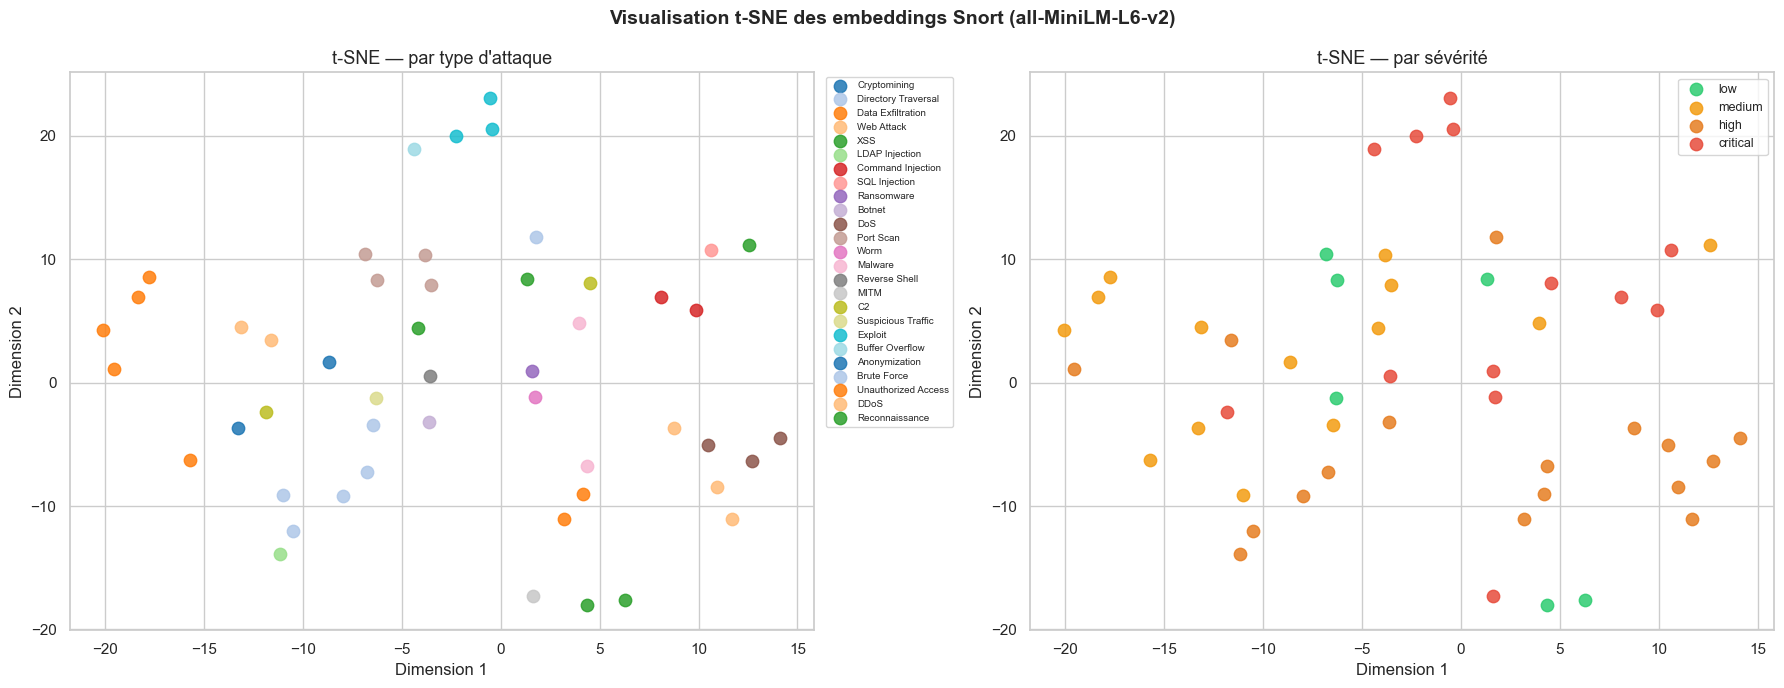

t-SNE sauvegardé dans ../Charts/02_tsne.png


In [15]:
# --- Couleurs par attack_type ---
attack_types = df['attack_type'].tolist()
unique_attacks = list(set(attack_types))
palette = sns.color_palette('tab20', len(unique_attacks))
color_map = {a: palette[i] for i, a in enumerate(unique_attacks)}
colors = [color_map[a] for a in attack_types]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -- Plot 1 : par attack_type --
for attack in unique_attacks:
    mask = [a == attack for a in attack_types]
    x = embeddings_2d[mask, 0]
    y = embeddings_2d[mask, 1]
    axes[0].scatter(x, y, label=attack, color=color_map[attack], s=80, alpha=0.85)

axes[0].set_title('t-SNE — par type d\'attaque', fontsize=13)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')

# -- Plot 2 : par severity --
severity_palette = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e67e22', 'critical': '#e74c3c'}
for sev, color in severity_palette.items():
    mask = df['severity'] == sev
    axes[1].scatter(
        embeddings_2d[mask, 0], embeddings_2d[mask, 1],
        label=sev, color=color, s=80, alpha=0.85
    )

axes[1].set_title('t-SNE — par sévérité', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')

plt.suptitle('Visualisation t-SNE des embeddings Snort (all-MiniLM-L6-v2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Charts/02_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE sauvegardé dans ../Charts/02_tsne.png')

## 9. Matrice de similarité cosine

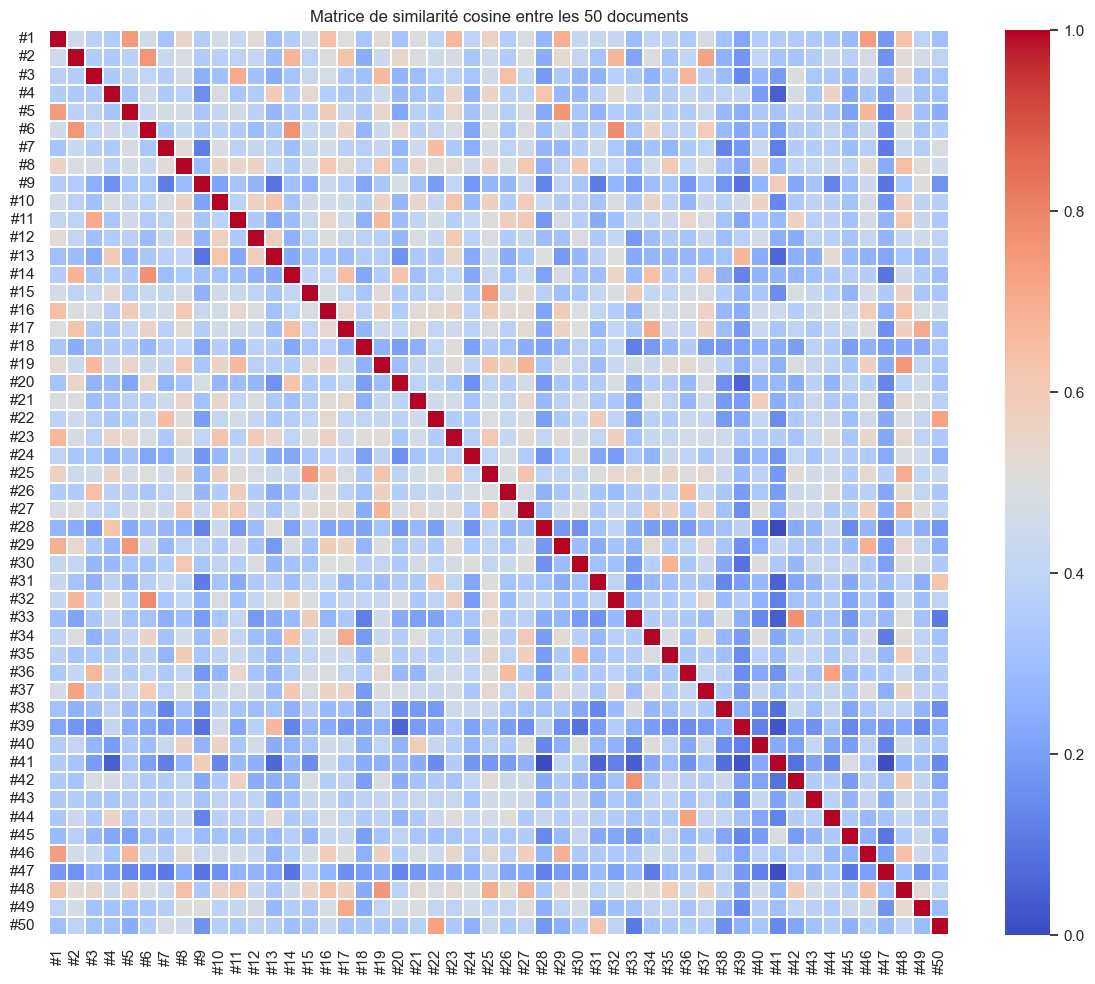

Matrice sauvegardée dans ../Charts/02_similarity_matrix.png


In [16]:
# Les embeddings sont déjà normalisés → similarité = produit scalaire
sim_matrix = np.dot(embeddings, embeddings.T)

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_matrix,
    cmap='coolwarm',
    vmin=0, vmax=1,
    xticklabels=[f'#{i+1}' for i in range(len(df))],
    yticklabels=[f'#{i+1}' for i in range(len(df))],
    linewidths=0.1
)
plt.title('Matrice de similarité cosine entre les 50 documents')
plt.tight_layout()
plt.savefig('../Charts/02_similarity_matrix.png', dpi=150)
plt.show()
print('Matrice sauvegardée dans ../Charts/02_similarity_matrix.png')

---
## ✅ Résumé
| Fichier généré | Contenu |
|---|---|
| `snort_faiss.index` | Index FAISS prêt pour le retrieval |
| `snort_embeddings.npy` | Matrice numpy des embeddings (50×384) |
| `snort_metadata.pkl` | Métadonnées du dataset (dict Python) |
| `02_tsne.png` | Visualisation t-SNE |
| `02_similarity_matrix.png` | Matrice de similarité cosine |